<a href="https://colab.research.google.com/github/mimingfikriac/EDA_Student_Habits_Performance/blob/main/EDA_Student_Habits_Performance_(Miming_Fikria_Camilla).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploratory Data Analysis (EDA)**
## **Student Habits & Academic Performance**

**Author:** Miming Fikria Camilla  
**Dataset Source**:  
https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance

Notebook ini berisi proses Exploratory Data Analysis (EDA) terhadap dataset *Student Habits and Academic Performance*.  
Tujuan dari analisis ini adalah untuk memahami pola kebiasaan siswa dan hubungannya dengan performa akademik.

Analisis mencakup data cleaning, eksplorasi data, visualisasi, serta insight yang diperoleh dari dataset.

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# **Upload File**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving student_habits_performance.csv to student_habits_performance.csv


In [3]:
df = pd.read_csv('student_habits_performance.csv', engine='python')

# **Check Data**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

**Keterangan masing-masing kolom sebagai berikut:**
1. **student_id** → ID unik siswa (tidak dipakai untuk analisis)
2. **age** → usia siswa (tahun)
3. **gender** → jenis kelamin siswa
4. **study_hours_per_day** → jam belajar per hari
5. **social_media_hours** → jam penggunaan media sosial per hari
6. **netflix_hours** → jam menonton Netflix/streaming per hari
7. **part_time_job** → status kerja paruh waktu (Yes/No)
8. **attendance_percentage** → persentase kehadiran (%)
9. **sleep_hours** → jam tidur per hari
10. diet_quality → kualitas pola makan (Poor/Average/Good)
11. **exercise_frequency** → frekuensi olahraga
12. **parental_education_level** → tingkat pendidikan orang tua
13. **internet_quality** → kualitas internet (Poor/Average/Good)
14. **mental_health_rating** → skor kesehatan mental
15. **extracurricular_participation** → ikut kegiatan ekstrakurikuler (Yes/No)
16. **exam_score** → nilai ujian akhir (target variabel)

Jumlah baris dan kolom pada dataset

In [5]:
df.shape

(1000, 16)

In [6]:
df.head(10)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
5,S1005,24,Male,7.2,1.3,0.0,No,82.9,7.4,Fair,1,Master,Average,4,No,100.0
6,S1006,21,Female,5.6,1.5,1.4,Yes,85.8,6.5,Good,2,Master,Poor,4,No,89.8
7,S1007,21,Female,4.3,1.0,2.0,Yes,77.7,4.6,Fair,0,Bachelor,Average,8,No,72.6
8,S1008,23,Female,4.4,2.2,1.7,No,100.0,7.1,Good,3,Bachelor,Good,1,No,78.9
9,S1009,18,Female,4.8,3.1,1.3,No,95.4,7.5,Good,5,Bachelor,Good,10,Yes,100.0


**Perhitungan numerik**

In [7]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [8]:
for col in df.columns:
  print(f"\n===={col}====")
  print(df[col].value_counts())


====student_id====
student_id
S1999    1
S1000    1
S1001    1
S1002    1
S1003    1
        ..
S1012    1
S1011    1
S1010    1
S1009    1
S1008    1
Name: count, Length: 1000, dtype: int64

====age====
age
20    146
24    134
17    133
21    125
23    119
18    117
19    113
22    113
Name: count, dtype: int64

====gender====
gender
Female    481
Male      477
Other      42
Name: count, dtype: int64

====study_hours_per_day====
study_hours_per_day
3.5    38
3.2    36
4.3    35
3.3    34
3.8    31
       ..
7.5     1
8.2     1
7.6     1
0.1     1
7.1     1
Name: count, Length: 78, dtype: int64

====social_media_hours====
social_media_hours
3.1    38
3.2    36
2.9    36
2.2    35
2.1    35
3.0    34
2.4    34
2.3    32
1.9    32
1.8    31
2.8    31
2.0    30
3.3    29
2.5    27
2.7    26
1.4    26
2.6    25
1.7    25
3.6    24
1.5    23
3.5    23
1.6    23
3.4    22
0.0    21
0.9    20
1.2    20
1.3    18
4.0    17
3.8    17
1.1    15
4.3    15
3.7    15
1.0    14
3.9    13
4.2    12


# **Check Missing Values**

In [9]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


Terdapat **91 missing values** pada kolom **parental_education_level**

In [10]:
df[df['parental_education_level'].isnull()]

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
10,S1010,19,Female,4.6,3.7,0.8,No,77.6,5.8,Fair,1,NaN,Good,3,No,63.3
33,S1033,18,Female,4.0,0.9,1.1,No,99.5,5.8,Poor,2,NaN,Average,5,No,70.7
47,S1047,23,Female,2.5,2.9,2.7,No,83.5,7.0,Good,4,NaN,Good,8,Yes,59.7
74,S1074,21,Female,2.3,1.0,0.4,No,100.0,6.4,Fair,6,NaN,Good,1,No,66.9
93,S1093,22,Male,4.1,2.5,3.0,No,85.1,5.8,Good,4,NaN,Good,5,No,70.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
921,S1921,23,Female,4.4,2.7,1.0,No,79.8,6.1,Fair,6,NaN,Average,3,No,85.4
925,S1925,19,Other,1.7,2.9,1.6,Yes,97.3,8.7,Good,1,NaN,Good,7,No,53.6
939,S1939,18,Female,4.7,3.2,1.9,No,75.2,5.4,Good,3,NaN,Good,6,No,71.0
945,S1945,23,Male,6.0,2.9,2.1,Yes,98.9,6.4,Poor,0,NaN,Average,7,No,100.0


Karena dataset memiliki 1000 baris dan terdapat **91 missing values**, maka baris NaN akan diimputasi. Data NaN diisi sebagai “Unknown” agar data tetap dapat digunakan tanpa mengurangi jumlah observasi.

In [11]:
df['parental_education_level']= df['parental_education_level'].fillna("Unknown")

Cek kembali missing values

In [12]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


# **Check Duplikat**

In [13]:
df.duplicated().sum()

np.int64(0)

Tidak ada data duplikat

# **Check Outlier**

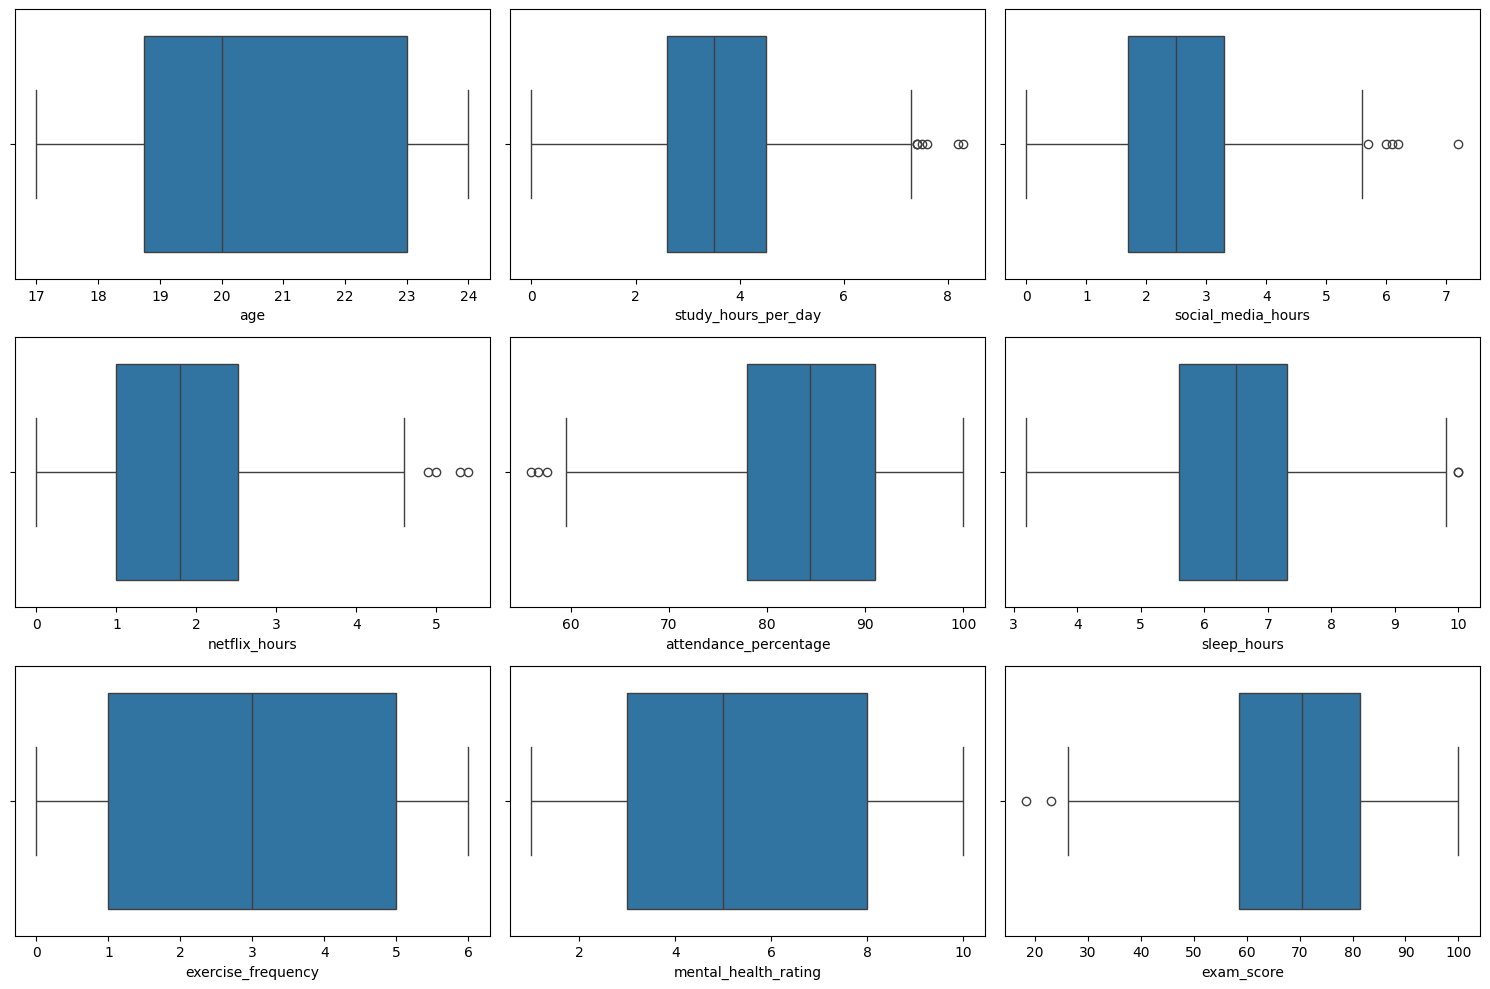

In [14]:
numerical_cols = ['age','study_hours_per_day','social_media_hours','netflix_hours','attendance_percentage','sleep_hours','exercise_frequency','mental_health_rating','exam_score']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col])
plt.tight_layout()
plt.show()

Berdasarkan boxplot di atas, ditemukan beberapa nilai outlier pada beberapa variabel seperti study_hours_per_day, social_media_hours, netflix_hours, sleep_hours, dan exam_score. Namun, nilai-nilai tersebut masih berada dalam rentang yang wajar secara konteks data siswa. Oleh karena itu, seluruh data tetap dipertahankan untuk menjaga informasi dalam analisis.

# **Eksplorasi dan Visualisasi Data**

**Analisis Korelasi Antar Variabel Numerik**

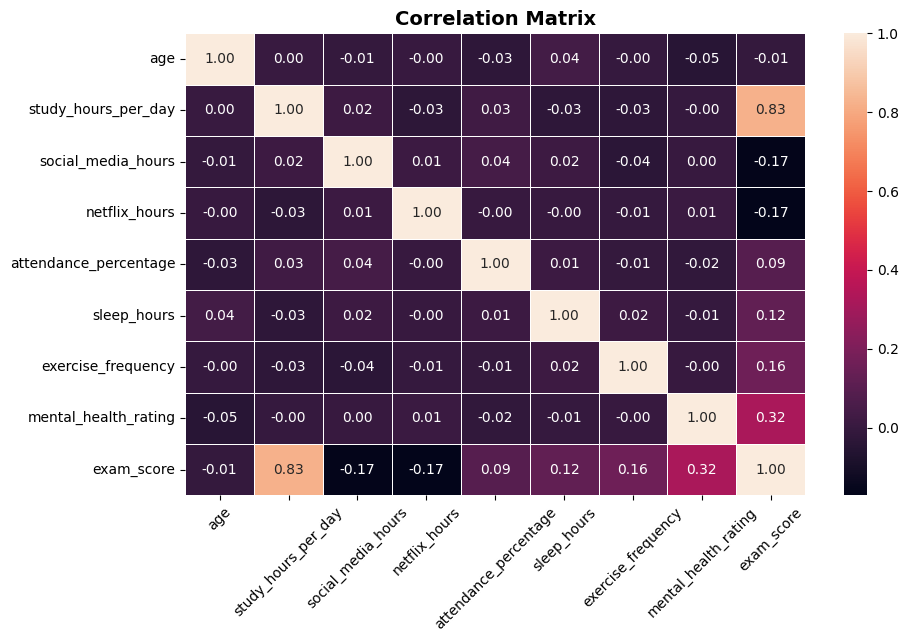

In [15]:
corr_matrix = df[['age','study_hours_per_day','social_media_hours',
                  'netflix_hours','attendance_percentage','sleep_hours',
                  'exercise_frequency','mental_health_rating','exam_score']].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

**Distribusi Setiap Variabel Kategorik**

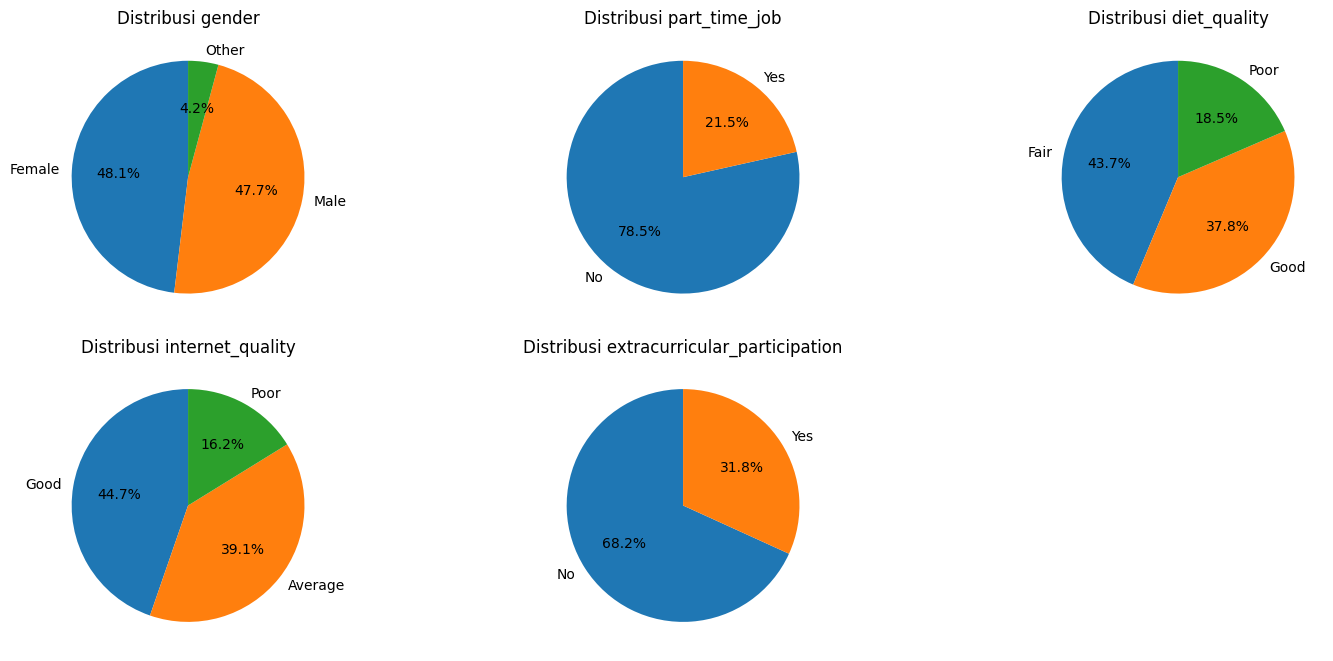

In [16]:
Kolom_Kategorik = ['gender', 'part_time_job', 'diet_quality','internet_quality', 'extracurricular_participation']
plt.figure(figsize=(15, 10))
for i, col in enumerate(Kolom_Kategorik, 1):
    plt.subplot(3, 3, i)
    plt.pie(df[col].value_counts(), labels=df[col].value_counts().index, autopct='%1.1f%%', startangle=90)
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

In [17]:
df.groupby('part_time_job')['study_hours_per_day'].mean()

,study_hours_per_day
part_time_job,
No,3.572484
Yes,3.468372


**Distribusi Variabel Numerik**

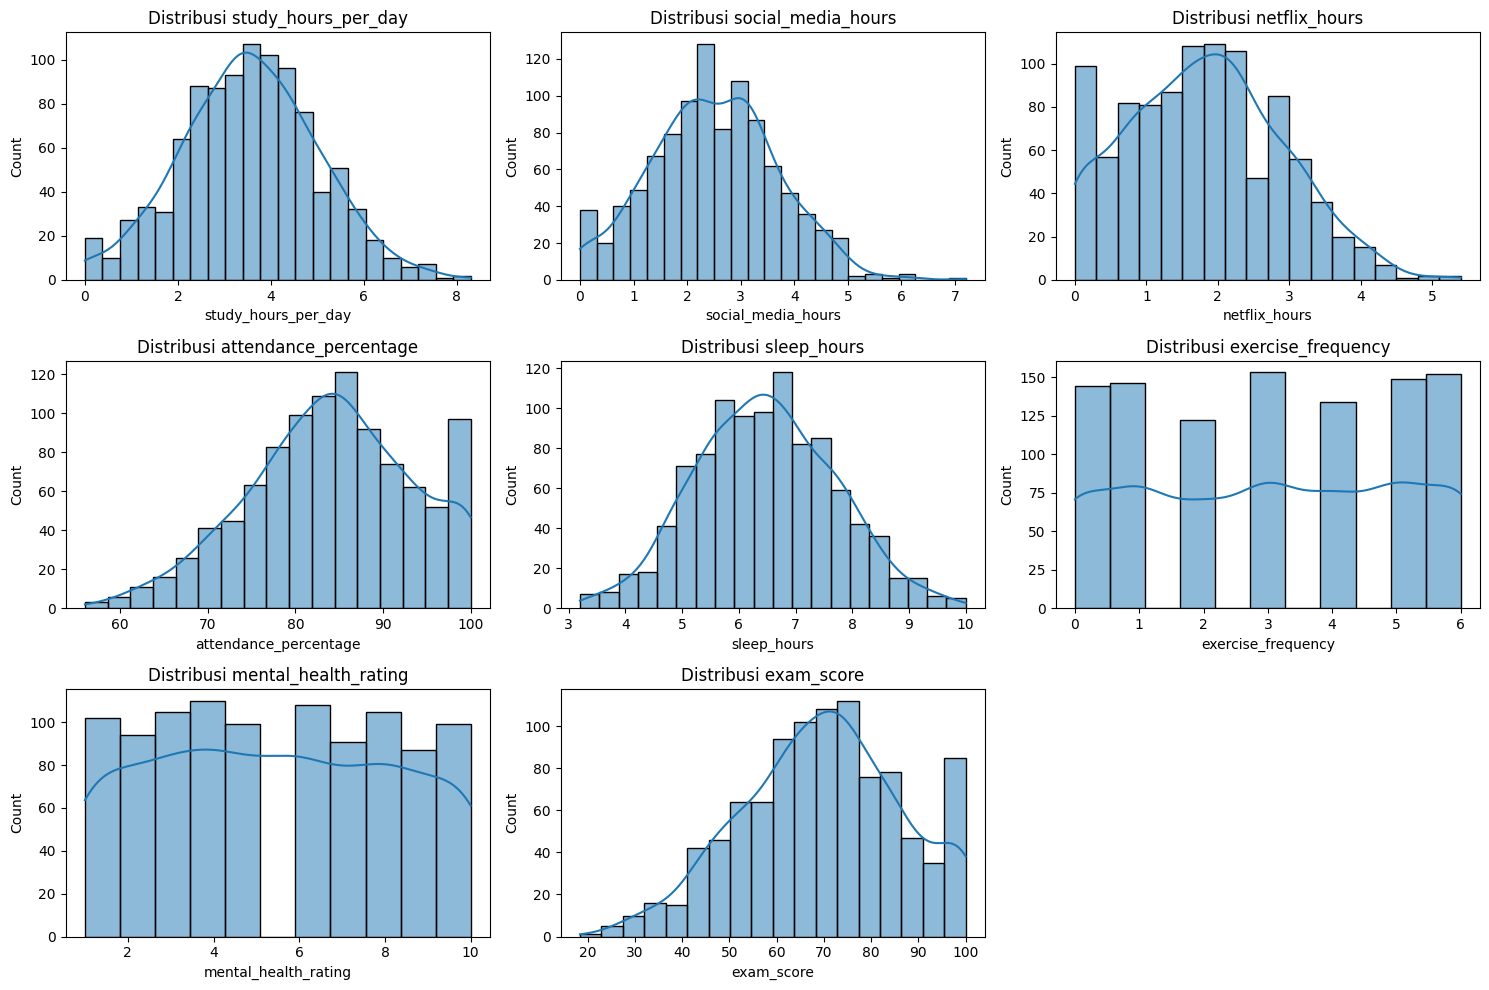

In [18]:
Kolom_Numerik = df[['study_hours_per_day','social_media_hours',
                  'netflix_hours','attendance_percentage','sleep_hours',
                  'exercise_frequency','mental_health_rating','exam_score']]

plt.figure(figsize=(15, 10))
for i, col in enumerate(Kolom_Numerik, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

**Korelasi antara variabel numerik terhadap nilai ujian (exam_score)**

In [19]:
df.corr(numeric_only=True)['exam_score'].sort_values(ascending=False)

,exam_score
exam_score,1.000000
study_hours_per_day,0.825419
mental_health_rating,0.321523
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907
social_media_hours,-0.166733
netflix_hours,-0.171779


Variabel **study_hours_per_day** memiliki korelasi positif yang sangat kuat (0.83) terhadap **exam_score**. Hal ini menunjukkan bahwa semakin banyak waktu belajar yang dilakukan siswa, maka semakin tinggi nilai ujian yang diperoleh. Variabel ini menjadi **faktor paling dominan** dalam menentukan performa akademik.

Lebih lanjut, Selain itu, beberapa faktor lain seperti **mental_health_rating**, **exercise_frequency**, dan **sleep_hours** juga memiliki korelasi positif terhadap **exam_score**, meskipun pengaruhnya tidak terlalu kuat. Hal ini menunjukkan bahwa kondisi mental yang baik, aktivitas fisik, dan waktu istirahat yang cukup tetap berkontribusi dalam mendukung performa akademik, namun tidak sebesar pengaruh waktu belajar.

Sementara itu, variabel **attendance_percentage** dan age menunjukkan hubungan yang sangat lemah terhadap **exam_score**, sehingga dapat dikatakan bahwa kedua faktor tersebut tidak memiliki pengaruh yang signifikan dalam dataset ini. Di sisi lain, variabel **social_media_hours** dan **netflix_hours** memiliki korelasi negatif terhadap **exam_score** (-0.17), yang mengindikasikan bahwa semakin banyak waktu yang dihabiskan untuk aktivitas hiburan seperti media sosial dan menonton Netflix, maka nilai ujian cenderung menurun. Hal ini kemungkinan disebabkan oleh berkurangnya waktu belajar serta meningkatnya distraksi dari aktivitas tersebut.

📊 **Analisis Rata-rata Exam Score Berdasarkan Variabel Kategorik**

Kode berikut digunakan untuk menghitung rata-rata nilai ujian (exam_score) berdasarkan setiap variabel kategorik pada dataset.

Hasil ini membantu melihat apakah terdapat perbedaan performa akademik antar kategori seperti gender, diet quality, internet quality, dan lainnya.

In [35]:
for col in df.select_dtypes(include='object').columns:
    print("\n" + "="*50)
    print(f"📊 RATA-RATA EXAM SCORE BERDASARKAN: {col}")
    print("="*50)

    result = df.groupby(col)['exam_score'].mean().sort_values()

    print(result.round(2))


📊 RATA-RATA EXAM SCORE BERDASARKAN: student_id
student_id
S1265     18.4
S1327     23.1
S1434     26.2
S1195     26.7
S1003     26.8
         ...  
S1455    100.0
S1945    100.0
S1437    100.0
S1222    100.0
S1219    100.0
Name: exam_score, Length: 1000, dtype: float64

📊 RATA-RATA EXAM SCORE BERDASARKAN: gender
gender
Male      69.37
Female    69.74
Other     70.65
Name: exam_score, dtype: float64

📊 RATA-RATA EXAM SCORE BERDASARKAN: part_time_job
part_time_job
Yes    68.74
No     69.84
Name: exam_score, dtype: float64

📊 RATA-RATA EXAM SCORE BERDASARKAN: diet_quality
diet_quality
Poor    68.13
Good    69.37
Fair    70.43
Name: exam_score, dtype: float64

📊 RATA-RATA EXAM SCORE BERDASARKAN: parental_education_level
parental_education_level
Master         68.09
High School    69.55
Unknown        70.03
Bachelor       70.27
Name: exam_score, dtype: float64

📊 RATA-RATA EXAM SCORE BERDASARKAN: internet_quality
internet_quality
Good       68.65
Poor       69.72
Average    70.64
Name: exa

Secara keseluruhan, variabel kategorik seperti gender, extracurricular participation, dan internet quality tidak menunjukkan perbedaan yang besar terhadap nilai ujian. Sementara itu, variabel seperti part-time job, diet quality, dan parental education level menunjukkan sedikit variasi, tetapi pengaruhnya masih relatif lemah dibandingkan faktor numerik seperti waktu belajar yang sebelumnya terbukti memiliki korelasi paling kuat.

# **SAVE CLEAN DATA**

In [21]:
# df_clean = df

In [22]:
# df_clean.to_csv("student_habits_clean.csv", index=False)

In [23]:
# from google.colab import files
# files.download("student_habits_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       1000 non-null   object 
 12  internet_quality               1000 non-null   ob

# **Machine Learning**

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [47]:
X = df.drop(['student_id', 'exam_score'], axis=1)
y = df['exam_score']

In [48]:
X = pd.get_dummies(X, drop_first=True)

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [51]:
model.coef_

array([ 0.05238008,  9.53153201, -2.68500449, -2.32153072,  0.14450769,
        1.97640719,  1.31964592,  1.95285623,  0.13429636,  0.810709  ,
        0.37092121, -0.95835558, -0.54631236, -0.45253117, -0.69872844,
       -0.83948281, -0.22276909, -0.02793773, -0.11094482])

In [52]:
model.intercept_

np.float64(6.866569281311797)

In [53]:
y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.8967502640380203
MAE: 4.189311054627605


In [54]:
coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coef = coef.sort_values(by='Coefficient', ascending=False)
print(coef)

                                 Feature  Coefficient
1                    study_hours_per_day     9.531532
5                            sleep_hours     1.976407
7                   mental_health_rating     1.952856
6                     exercise_frequency     1.319646
9                           gender_Other     0.810709
10                     part_time_job_Yes     0.370921
4                  attendance_percentage     0.144508
8                            gender_Male     0.134296
0                                    age     0.052380
17                 internet_quality_Poor    -0.027938
18     extracurricular_participation_Yes    -0.110945
16                 internet_quality_Good    -0.222769
13  parental_education_level_High School    -0.452531
12                     diet_quality_Poor    -0.546312
14       parental_education_level_Master    -0.698728
15      parental_education_level_Unknown    -0.839483
11                     diet_quality_Good    -0.958356
3                          n

Hasil model menunjukkan bahwa faktor paling berpengaruh terhadap nilai ujian adalah waktu belajar harian. Sebaliknya, penggunaan media sosial dan menonton Netflix memiliki dampak negatif yang signifikan terhadap performa akademik siswa.